# Knee Joint Localization using YOLO11

## Dissertation Project

This notebook implements the complete pipeline for knee joint localization using YOLO11.

### Workflow

1. Environment Setup
2. Dataset Verification
3. Dataset Preparation
4. Model Training
5. Model Evaluation
6. Prediction Visualization
7. Automatic Annotation
8. Model Retraining
9. Performance Comparison

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages

!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.9 MB/s eta 0:00:00


In [ ]:
# Import libraries

from pathlib import Path
import os
import shutil
import random
import yaml

import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Define project folder

PROJECT_ROOT = Path("/content/drive/MyDrive/Knee_YOLO_Project")

## Create Project Folder Structure

This section automatically creates the project folders required for the dissertation.

In [ ]:
# Create complete folder structure

folders = [
    "Datasets/raw/images",
    "Datasets/raw/labels",

    "Datasets/dataset_30",
    "Datasets/dataset_50",
    "Datasets/dataset_70",
    "Datasets/dataset_100",

    "Models",

    "Results",

    "Predictions",

    "Graphs"
]

for folder in folders:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("="*50)
print("Project folder structure created successfully!")
print("="*50)

Project folder structure created successfully!


In [ ]:
# Display folder structure

for item in PROJECT_ROOT.iterdir():
    print(item)

/content/drive/MyDrive/Knee_YOLO_Project/Datasets
/content/drive/MyDrive/Knee_YOLO_Project/Models
/content/drive/MyDrive/Knee_YOLO_Project/Results
/content/drive/MyDrive/Knee_YOLO_Project/Predictions
/content/drive/MyDrive/Knee_YOLO_Project/Graphs


# Dataset Verification

This section verifies that the dataset has been uploaded correctly.

The following checks will be performed:

- Count images
- Count annotation files
- Verify image-label pairs
- Validate YOLO annotation format
- Visualize sample annotations

In [ ]:
# Dataset paths

RAW_IMAGES = PROJECT_ROOT / "Datasets" / "raw" / "images"
RAW_LABELS = PROJECT_ROOT / "Datasets" / "raw" / "labels"

print("Images Folder :", RAW_IMAGES)
print("Labels Folder :", RAW_LABELS)

Images Folder : /content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/images
Labels Folder : /content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/labels


In [ ]:
# Count images and labels

image_extensions = ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]

image_files = []

for ext in image_extensions:
    image_files.extend(list(RAW_IMAGES.glob(ext)))

label_files = list(RAW_LABELS.glob("*.txt"))

print("="*40)
print("DATASET SUMMARY")
print("="*40)
print(f"Images : {len(image_files)}")
print(f"Labels : {len(label_files)}")
print("="*40)

DATASET SUMMARY
Images : 30
Labels : 30


In [ ]:
# Verify image-label pairs

missing_labels = []

for img in image_files:
    label = RAW_LABELS / f"{img.stem}.txt"

    if not label.exists():
        missing_labels.append(img.name)

if len(missing_labels) == 0:
    print("✅ Every image has a corresponding label.")
else:
    print("❌ Missing labels:")
    for item in missing_labels:
        print(item)

✅ Every image has a corresponding label.


In [ ]:
# Verify YOLO label format

invalid_labels = []

for label_file in label_files:

    with open(label_file) as f:
        lines = f.readlines()

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            invalid_labels.append(label_file.name)

if len(invalid_labels) == 0:
    print("✅ All labels are in valid YOLO format.")
else:
    print("❌ Invalid label files:")
    print(set(invalid_labels))

✅ All labels are in valid YOLO format.


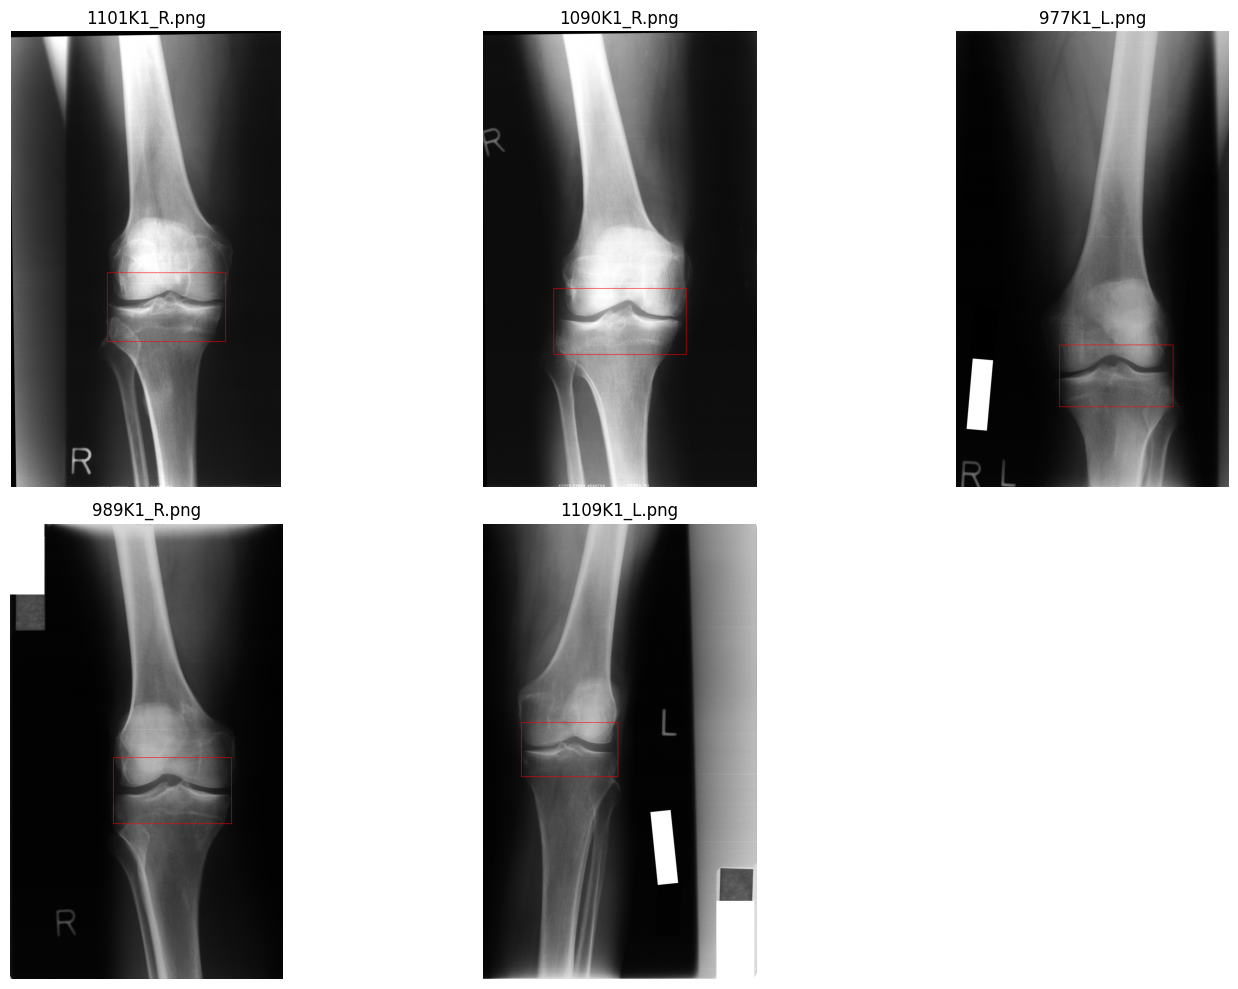

In [ ]:
# Display 5 random images with bounding boxes

import random

sample_images = random.sample(image_files, min(5, len(image_files)))

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_images):

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = RAW_LABELS / f"{img_path.stem}.txt"

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls, xc, yc, bw, bh = map(float, line.split())

        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255,0,0), 4)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()

In [ ]:
print("="*50)
print("DATASET VERIFICATION COMPLETED")
print("="*50)

print(f"Total Images : {len(image_files)}")
print(f"Total Labels : {len(label_files)}")

print("\nDataset is ready for YOLO11 training.")

DATASET VERIFICATION COMPLETED
Total Images : 30
Total Labels : 30

Dataset is ready for YOLO11 training.


# Dataset Preparation

This section prepares the dataset for YOLO11 training by:

- Splitting the dataset into Train, Validation and Test sets
- Copying images and labels
- Creating the YOLO data.yaml configuration file

In [ ]:
import random
import shutil
from pathlib import Path

random.seed(42)

DATASET30 = PROJECT_ROOT / "Datasets" / "dataset_30"

splits = ["train", "valid", "test"]

for split in splits:
    (DATASET30 / split / "images").mkdir(parents=True, exist_ok=True)
    (DATASET30 / split / "labels").mkdir(parents=True, exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [ ]:
# Shuffle images

images = sorted(list(RAW_IMAGES.glob("*.png")))

random.shuffle(images)

total = len(images)

train_size = int(total * 0.8)
valid_size = int(total * 0.1)

train_images = images[:train_size]
valid_images = images[train_size:train_size+valid_size]
test_images = images[train_size+valid_size:]

print("Train :", len(train_images))
print("Valid :", len(valid_images))
print("Test  :", len(test_images))

Train : 24
Valid : 3
Test  : 3


In [ ]:
def copy_dataset(image_list, split):

    for img in image_list:

        label = RAW_LABELS / (img.stem + ".txt")

        shutil.copy2(
            img,
            DATASET30 / split / "images" / img.name
        )

        shutil.copy2(
            label,
            DATASET30 / split / "labels" / label.name
        )


copy_dataset(train_images, "train")
copy_dataset(valid_images, "valid")
copy_dataset(test_images, "test")

print("Dataset copied successfully.")

Dataset copied successfully.


In [ ]:
# Create data.yaml

data_yaml = {
    "path": str(DATASET30),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {
        0: "knee"
    }
}

yaml_path = DATASET30 / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created.")

data.yaml created.


In [ ]:
# Verify dataset

for split in ["train", "valid", "test"]:

    imgs = list((DATASET30 / split / "images").glob("*"))
    labels = list((DATASET30 / split / "labels").glob("*"))

    print(f"{split.upper()}")

    print("Images :", len(imgs))
    print("Labels :", len(labels))
    print("-"*30)

TRAIN
Images : 24
Labels : 24
------------------------------
VALID
Images : 3
Labels : 3
------------------------------
TEST
Images : 3
Labels : 3
------------------------------


In [ ]:
print("="*50)
print("Dataset preparation completed successfully!")
print("="*50)

print(f"Dataset location:\n{DATASET30}")

Dataset preparation completed successfully!
Dataset location:
/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_30


# Train YOLO11n Baseline Model

This experiment trains the YOLO11n object detection model using the
30-image dataset.

Training Parameters

- Model: YOLO11n
- Epochs: 100
- Image Size: 640 × 640
- Batch Size: 8
- Optimizer: Auto
- Device: GPU

In [ ]:
# Check GPU

import torch

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA Available : True
GPU : Tesla T4


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Load YOLO11n model

model = YOLO("yolo11n.pt")

print("YOLO11n model loaded successfully.")

YOLO11n model loaded successfully.


In [ ]:
# Start training

results = model.train(

    data=str(DATASET30 / "data.yaml"),

    epochs=100,

    imgsz=640,

    batch=8,

    project=str(PROJECT_ROOT / "Results"),

    name="YOLO11n_30",

    exist_ok=True,

    device=0,

    workers=2,

    pretrained=True,

    verbose=True
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_30/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_30, nbs=64, nms=False, opset=None, 

In [ ]:
print("Training completed successfully!")

Training completed successfully!


In [ ]:
# Evaluate the Model
best_model = YOLO(PROJECT_ROOT / "Results" / "YOLO11n_30" / "weights" / "best.pt")

metrics = best_model.val(
    data=str(DATASET30 / "data.yaml")
)

print(metrics)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 501.8±72.2 MB/s, size: 4652.3 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_30/valid/labels.cache... 3 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 786.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all          3          3      0.986          1      0.995      0.846
Speed: 0.4ms preprocess, 17.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e3d1c5ed310>
curves: ['Precisio

In [ ]:
# Store evaluation results
results_30 = {
    "Dataset Size": 30,
    "Training Images": 24,
    "Validation Images": 3,
    "Test Images": 3,
    "Precision": round(metrics.box.mp, 4),
    "Recall": round(metrics.box.mr, 4),
    "mAP@50": round(metrics.box.map50, 4),
    "mAP@50:95": round(metrics.box.map, 4)
}

results_30

{'Dataset Size': 30,
 'Training Images': 24,
 'Validation Images': 3,
 'Test Images': 3,
 'Precision': np.float64(0.986),
 'Recall': np.float64(1.0),
 'mAP@50': np.float64(0.995),
 'mAP@50:95': np.float64(0.775)}

In [ ]:
results_folder = PROJECT_ROOT / "Results" / "YOLO11n_30"

print(results_folder)

/content/drive/MyDrive/Knee_YOLO_Project/Results/YOLO11n_30


# Test Set Predictions

This section uses the trained YOLO11n model to predict knee joint locations on the unseen test dataset and visualizes the detection results.

In [ ]:
from pathlib import Path
from ultralytics import YOLO

PROJECT_ROOT = Path("/content/drive/MyDrive/Knee_YOLO_Project")

MODEL_PATH = PROJECT_ROOT / "Results" / "YOLO11n_30" / "weights" / "best.pt"

TEST_IMAGES = PROJECT_ROOT / "Datasets" / "dataset_30" / "test" / "images"

PREDICT_DIR = PROJECT_ROOT / "Predictions" / "YOLO11n_30"

model = YOLO(str(MODEL_PATH))

In [ ]:
from pathlib import Path

detect_dir = Path("/content/runs/detect")

print("Folders inside /content/runs/detect:\n")

for folder in sorted(detect_dir.iterdir()):
    print(folder)

Folders inside /content/runs/detect:

/content/runs/detect/predict
/content/runs/detect/val


In [ ]:
from pathlib import Path

prediction_dir = Path("/content/runs/detect/predict")

print("Prediction directory:", prediction_dir)
print("Exists:", prediction_dir.exists())

print("\nAll files inside predict:")

for f in prediction_dir.rglob("*"):
    print(f)

Prediction directory: /content/runs/detect/predict
Exists: True

All files inside predict:
/content/runs/detect/predict/1250K1_R.jpg
/content/runs/detect/predict/1013K1_L.jpg
/content/runs/detect/predict/1002K1_R.jpg


Found 3 prediction images.


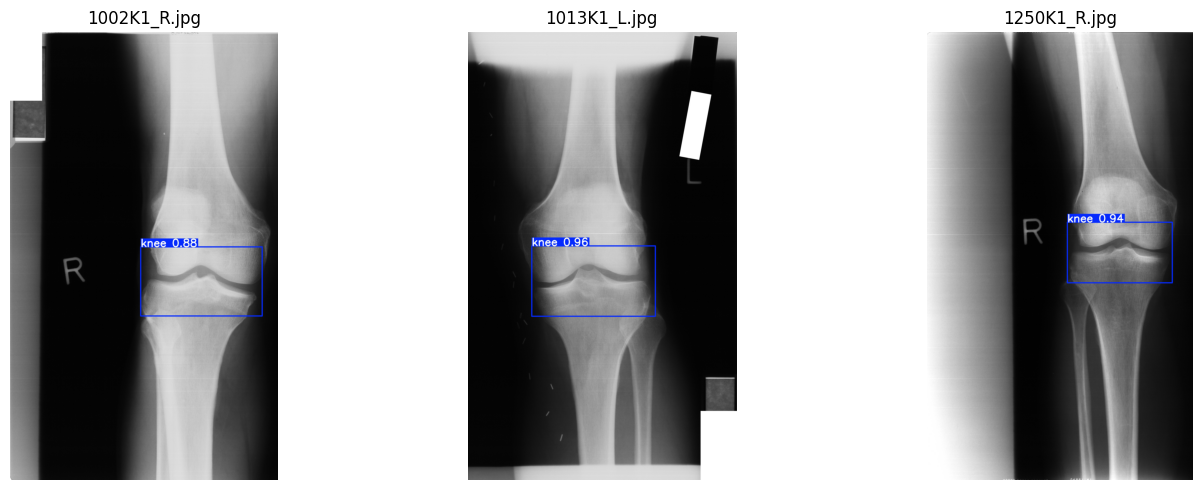

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

prediction_dir = Path("/content/runs/detect/predict")

# Find both JPG and PNG images
prediction_images = sorted(
    list(prediction_dir.glob("*.jpg")) +
    list(prediction_dir.glob("*.png")) +
    list(prediction_dir.glob("*.jpeg"))
)

print(f"Found {len(prediction_images)} prediction images.")

plt.figure(figsize=(15,5))

for i, img_path in enumerate(prediction_images):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(prediction_images), i + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Knee_YOLO_Project")

prediction_source = Path("/content/runs/detect/predict")
prediction_dest = PROJECT_ROOT / "Predictions" / "YOLO11n_30"

prediction_dest.mkdir(parents=True, exist_ok=True)

for file in prediction_source.glob("*"):
    shutil.copy(file, prediction_dest / file.name)

print("Predictions saved to:")
print(prediction_dest)

Predictions saved to:
/content/drive/MyDrive/Knee_YOLO_Project/Predictions/YOLO11n_30


# **Experiment-2 (50 Images)**

# Dataset Preparation (50 Images)

This section prepares the 50-image dataset by splitting it into training, validation and testing sets.

Dataset Split:

- Training: 80%
- Validation: 10%
- Testing: 10%

This dataset will be used to continue training the YOLO11n model using the best weights obtained from the 30-image experiment.

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Knee_YOLO_Project"

DATASETS_DIR = os.path.join(PROJECT_DIR, "Datasets")

RAW_DIR = os.path.join(DATASETS_DIR, "raw")

RAW_IMAGES_DIR = os.path.join(RAW_DIR, "images")
RAW_LABELS_DIR = os.path.join(RAW_DIR, "labels")

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "Predictions")

DATASET_50_DIR = os.path.join(DATASETS_DIR, "dataset_50")
DATASET_50_YAML = os.path.join(DATASET_50_DIR, "data.yaml")

In [ ]:
import os

images = sorted([
    f for f in os.listdir(RAW_IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
])

labels = sorted([
    f for f in os.listdir(RAW_LABELS_DIR)
    if f.endswith(".txt")
])

print(f"Images : {len(images)}")
print(f"Labels : {len(labels)}")

Images : 50
Labels : 50


### Create Dataset (50 Images)

This section creates the 50-image dataset from the annotated raw images.

The dataset is randomly divided into:

- Training: 80%
- Validation: 10%
- Testing: 10%

A `data.yaml` file is also generated for YOLO training.

In [ ]:
import os
import random
import shutil
from sklearn.model_selection import train_test_split

# -----------------------------
# Configuration
# -----------------------------

DATASET_SIZE = 50
SEED = 42

PROJECT_DIR = "/content/drive/MyDrive/Knee_YOLO_Project"

RAW_IMAGES_DIR = os.path.join(PROJECT_DIR, "Datasets/raw/images")
RAW_LABELS_DIR = os.path.join(PROJECT_DIR, "Datasets/raw/labels")

DATASET_50_DIR = os.path.join(PROJECT_DIR, "Datasets/dataset_50")

random.seed(SEED)

# Remove old dataset if it exists
if os.path.exists(DATASET_50_DIR):
    shutil.rmtree(DATASET_50_DIR)

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(DATASET_50_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(DATASET_50_DIR, split, "labels"), exist_ok=True)

# Read all images (supports TIFF)
image_files = sorted([
    f for f in os.listdir(RAW_IMAGES_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
])

image_files = image_files[:DATASET_SIZE]

print(f"Total Images Used : {len(image_files)}")

Total Images Used : 50


In [ ]:
train_files, temp_files = train_test_split(
    image_files,
    test_size=0.20,
    random_state=SEED
)

valid_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=SEED
)

print(f"Training Images   : {len(train_files)}")
print(f"Validation Images : {len(valid_files)}")
print(f"Testing Images    : {len(test_files)}")

Training Images   : 40
Validation Images : 5
Testing Images    : 5


In [ ]:
def copy_files(files, split):

    for image in files:

        image_src = os.path.join(RAW_IMAGES_DIR, image)

        label = os.path.splitext(image)[0] + ".txt"
        label_src = os.path.join(RAW_LABELS_DIR, label)

        shutil.copy(
            image_src,
            os.path.join(DATASET_50_DIR, split, "images", image)
        )

        shutil.copy(
            label_src,
            os.path.join(DATASET_50_DIR, split, "labels", label)
        )

copy_files(train_files, "train")
copy_files(valid_files, "valid")
copy_files(test_files, "test")

print("Dataset Created Successfully.")

Dataset Created Successfully.


In [ ]:
yaml_content = f"""
path: {DATASET_50_DIR}

train: train/images
val: valid/images
test: test/images

names:
  0: Knee
"""

with open(os.path.join(DATASET_50_DIR, "data.yaml"), "w") as f:
    f.write(yaml_content)

print("data.yaml created.")

data.yaml created.


In [ ]:
for split in ["train", "valid", "test"]:

    images = len(os.listdir(os.path.join(DATASET_50_DIR, split, "images")))
    labels = len(os.listdir(os.path.join(DATASET_50_DIR, split, "labels")))

    print(f"{split.capitalize()} -> Images: {images} | Labels: {labels}")

Train -> Images: 40 | Labels: 40
Valid -> Images: 5 | Labels: 5
Test -> Images: 5 | Labels: 5


# Continue Training YOLO11n

This experiment continues training from the best model obtained during the 30-image experiment.

Training Dataset:
- dataset_50

Starting Weights:
- Results/YOLO11n_30/weights/best.pt

In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import YOLO
import os

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")

previous_weights = os.path.join(
    RESULTS_DIR,
    "YOLO11n_30",
    "weights",
    "best.pt"
)

DATASET_50_YAML = os.path.join(DATASET_50_DIR, "data.yaml")

model = YOLO(previous_weights)

In [ ]:
results = model.train(

    data=DATASET_50_YAML,

    epochs=100,

    imgsz=640,

    batch=8,

    project=RESULTS_DIR,

    name="YOLO11n_50",

    exist_ok=True
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Knee_YOLO_Project/Results/YOLO11n_30/weights/best.pt, momentum=0.937, mosaic=1.0, m

# Model Evaluation

Evaluate the trained YOLO11n model using the testing dataset.

Metrics recorded:

- Precision
- Recall
- mAP@50
- mAP@50:95

In [ ]:
best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_50",
        "weights",
        "best.pt"
    )
)

metrics = best_model.val(
    data=DATASET_50_YAML
)

results_50 = {
    "Dataset Size": 50,
    "Training Images": 40,
    "Validation Images": 5,
    "Test Images": 5,
    "Precision": round(metrics.box.mp, 4),
    "Recall": round(metrics.box.mr, 4),
    "mAP@50": round(metrics.box.map50, 4),
    "mAP@50:95": round(metrics.box.map, 4)
}

results_50

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 384.6±126.2 MB/s, size: 3834.7 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all          5          5      0.986          1      0.995      0.775
Speed: 0.3ms preprocess, 4.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val-6


{'Dataset Size': 50,
 'Training Images': 40,
 'Validation Images': 5,
 'Test Images': 5,
 'Precision': np.float64(0.986),
 'Recall': np.float64(1.0),
 'mAP@50': np.float64(0.995),
 'mAP@50:95': np.float64(0.775)}

# Generate Predictions

Generate predictions using the testing images from the 50-image dataset.

In [ ]:
TEST_IMAGES = os.path.join(
    DATASET_50_DIR,
    "test",
    "images"
)

best_model.predict(
    source=TEST_IMAGES,
    save=True,
    conf=0.25
)


image 1/5 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/test/images/1123K1_L.png: 640x384 1 Knee, 131.1ms
image 2/5 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/test/images/53412K1_L.png: 640x384 1 Knee, 20.2ms
image 3/5 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/test/images/53428K1_R.png: 640x384 1 Knee, 15.6ms
image 4/5 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/test/images/53512K1_L.png: 640x384 1 Knee, 12.9ms
image 5/5 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/test/images/989K1_R.png: 640x384 1 Knee, 30.4ms
Speed: 5.0ms preprocess, 42.1ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Knee'}
 obb: None
 orig_img: array([[[205, 205, 205],
         [205, 205, 205],
         [206, 206, 206],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[201, 201, 201],
         [199, 199, 199],
         [199, 199, 199],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[197, 197, 197],
         [194, 194, 194],
         [194, 194, 194],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        ...,
 
        [[106, 106, 106],
         [106, 106, 106],
         [108, 108, 108],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[107, 107, 107],
         [107, 107, 107],
         [108, 108, 108],
         ...,
         [  0,   0, 

# Display Prediction Results

Visualise the predicted bounding boxes produced by the trained model.

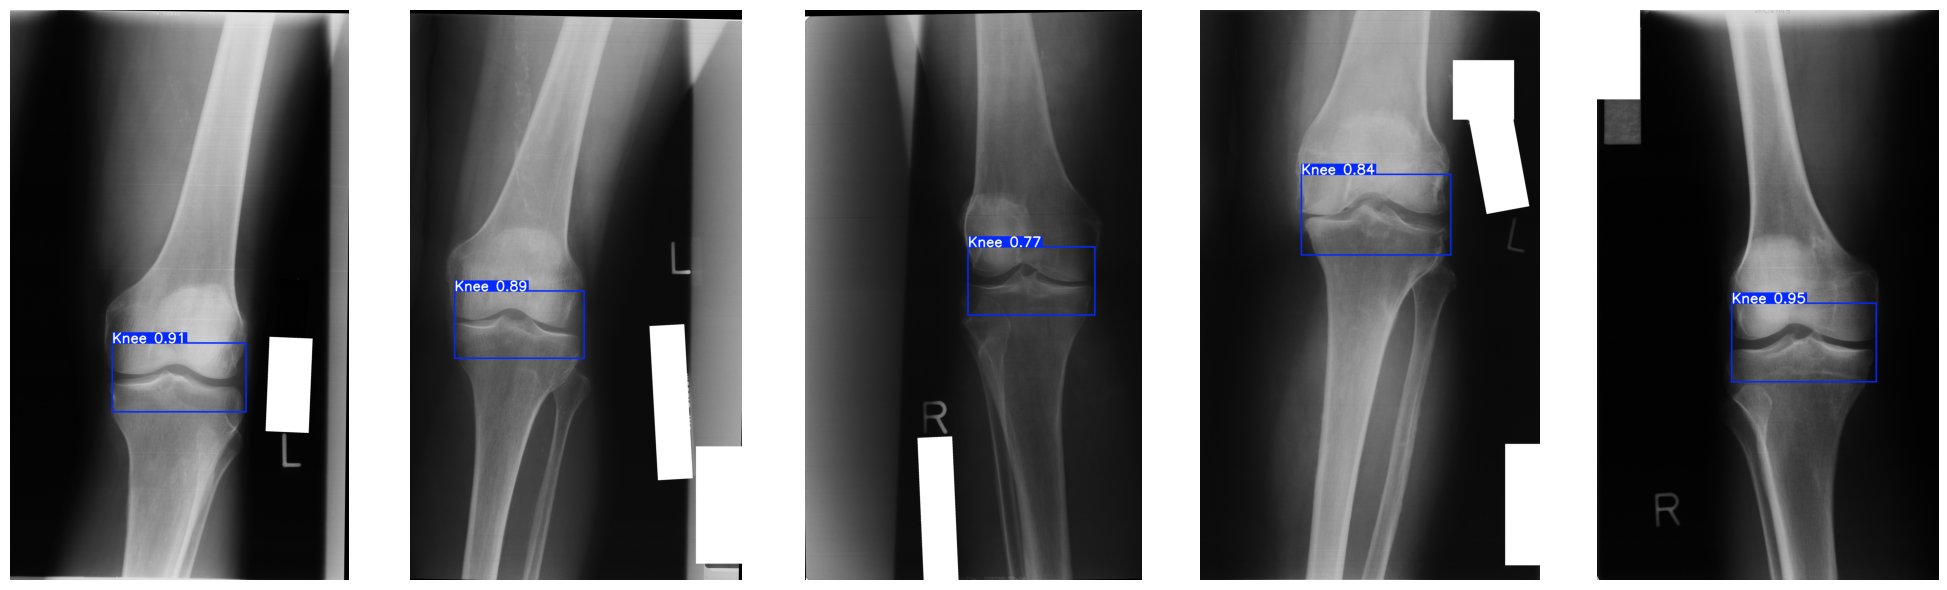

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt

prediction_folder = "/content/runs/detect/predict"

prediction_images = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]:
    prediction_images.extend(
        glob.glob(os.path.join(prediction_folder, ext))
    )

prediction_images = sorted(prediction_images)

plt.figure(figsize=(20,6))

for i, img_path in enumerate(prediction_images):

    image = cv2.imread(img_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(prediction_images), i+1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

# YOLO prediction folder
SOURCE = "/content/runs/detect/predict"

# Destination in Google Drive
DESTINATION = os.path.join(
    PROJECT_DIR,
    "Predictions",
    "YOLO11n_50"
)

# Create Predictions folder if it doesn't exist
os.makedirs(os.path.join(PROJECT_DIR, "Predictions"), exist_ok=True)

# If YOLO11n_50 already exists, create a timestamped backup instead of overwriting
if os.path.exists(DESTINATION):
    import datetime

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    DESTINATION = os.path.join(
        PROJECT_DIR,
        "Predictions",
        f"YOLO11n_50_{timestamp}"
    )

shutil.copytree(SOURCE, DESTINATION)

print("Predictions saved to:")
print(DESTINATION)

Predictions saved to:
/content/drive/MyDrive/Knee_YOLO_Project/Predictions/YOLO11n_50


In [ ]:
best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_50",
        "weights",
        "best.pt"
    )
)

metrics = best_model.val(
    data=DATASET_50_YAML
)

print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 430.5±32.9 MB/s, size: 3834.7 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_50/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 998.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          5          5      0.986          1      0.995      0.775
Speed: 0.4ms preprocess, 4.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val-3
Precision : 0.9860
Recall    : 1.0000
mAP50     : 0.9950
mAP50-95  : 0.7750


# **Experiment - 3 (70 Images)**

# Dataset Preparation (70 Images)

This section prepares the 70-image dataset by splitting it into training, validation and testing sets.

Dataset Split:

- Training: 80%
- Validation: 10%
- Testing: 10%

This dataset will be used to continue training the YOLO11n model using the best weights obtained from the 50-image experiment.

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Knee_YOLO_Project"

DATASETS_DIR = os.path.join(PROJECT_DIR, "Datasets")

RAW_DIR = os.path.join(DATASETS_DIR, "raw")

RAW_IMAGES_DIR = os.path.join(RAW_DIR, "images")
RAW_LABELS_DIR = os.path.join(RAW_DIR, "labels")

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "Predictions")

DATASET_70_DIR = os.path.join(DATASETS_DIR, "dataset_70")
DATASET_70_YAML = os.path.join(DATASET_50_DIR, "data.yaml")

In [ ]:
import os

images = sorted([
    f for f in os.listdir(RAW_IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
])

labels = sorted([
    f for f in os.listdir(RAW_LABELS_DIR)
    if f.endswith(".txt")
])

print(f"Images : {len(images)}")
print(f"Labels : {len(labels)}")

Images : 70
Labels : 70


# Create Dataset (70 Images)

This section creates the 70-image dataset by:

- Selecting 70 annotated images
- Splitting them into:
  - 80% Training
  - 10% Validation
  - 10% Testing
- Copying images and labels
- Creating the data.yaml file

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# -------------------------------
# Configuration
# -------------------------------

DATASET_SIZE = 70
SEED = 42

random.seed(SEED)

RAW_IMAGES_DIR = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/images"
RAW_LABELS_DIR = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/raw/labels"

DATASET_DIR = "/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70"

# Remove previous dataset if it exists
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(DATASET_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(DATASET_DIR, split, "labels"), exist_ok=True)

# -------------------------------
# Read Images
# -------------------------------

image_files = sorted([
    f for f in os.listdir(RAW_IMAGES_DIR)
    if f.lower().endswith((
        ".jpg",
        ".jpeg",
        ".png",
        ".tif",
        ".tiff"
    ))
])

image_files = image_files[:DATASET_SIZE]

print(f"Using {len(image_files)} images")

Using 70 images


In [ ]:
# Train / Validation / Test Split

train_files, temp_files = train_test_split(
    image_files,
    test_size=0.20,
    random_state=SEED
)

valid_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=SEED
)

print("Training :", len(train_files))
print("Validation :", len(valid_files))
print("Testing :", len(test_files))

Training : 56
Validation : 7
Testing : 7


In [ ]:
def copy_dataset(files, split):

    for image in files:

        image_src = os.path.join(RAW_IMAGES_DIR, image)

        label = os.path.splitext(image)[0] + ".txt"
        label_src = os.path.join(RAW_LABELS_DIR, label)

        shutil.copy(
            image_src,
            os.path.join(DATASET_DIR, split, "images", image)
        )

        shutil.copy(
            label_src,
            os.path.join(DATASET_DIR, split, "labels", label)
        )


copy_dataset(train_files, "train")
copy_dataset(valid_files, "valid")
copy_dataset(test_files, "test")

print("Dataset created successfully.")

Dataset created successfully.


In [ ]:
yaml_text = f"""
path: {DATASET_DIR}

train: train/images
val: valid/images
test: test/images

names:
  0: Knee
"""

with open(os.path.join(DATASET_DIR, "data.yaml"), "w") as f:
    f.write(yaml_text)

print("data.yaml created successfully.")

data.yaml created successfully.


In [ ]:
print("\nDataset Summary\n")

for split in ["train", "valid", "test"]:

    images = len(os.listdir(os.path.join(DATASET_DIR, split, "images")))
    labels = len(os.listdir(os.path.join(DATASET_DIR, split, "labels")))

    print(f"{split.capitalize():10} Images: {images}   Labels: {labels}")


Dataset Summary

Train      Images: 56   Labels: 56
Valid      Images: 7   Labels: 7
Test       Images: 7   Labels: 7


# Continue Training YOLO11n

This experiment continues training from the best model obtained during the 50-image experiment.

Training Dataset:
- dataset_70

Starting Weights:
- Results/YOLO11n_50/weights/best.pt

In [ ]:
from ultralytics import YOLO
import os

RESULTS_DIR = os.path.join(PROJECT_DIR, "Results")

previous_weights = os.path.join(
    RESULTS_DIR,
    "YOLO11n_50",
    "weights",
    "best.pt"
)

DATASET_70_YAML = os.path.join(DATASET_70_DIR, "data.yaml")

model = YOLO(previous_weights)

In [ ]:
results = model.train(

    data=DATASET_70_YAML,

    epochs=100,

    imgsz=640,

    batch=8,

    project=RESULTS_DIR,

    name="YOLO11n_70",

    exist_ok=True
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Knee_YOLO_Project/Results/YOLO11n_50/weights/best.pt, momentum=0.937, mosaic=1.0, m

# Model Evaluation

Evaluate the trained YOLO11n model using the testing dataset.

Metrics recorded:

- Precision
- Recall
- mAP@50
- mAP@50:95

In [ ]:
from ultralytics import YOLO
import os

# Load the best model
best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_70",
        "weights",
        "best.pt"
    )
)

# Evaluate the model
metrics = best_model.val(
    data=DATASET_70_YAML
)

# Display evaluation metrics
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")

# Store results for the summary table
results_70 = {
    "Dataset Size": 70,
    "Training Images": 56,
    "Validation Images": 7,
    "Test Images": 7,
    "Precision": round(metrics.box.mp, 4),
    "Recall": round(metrics.box.mr, 4),
    "mAP@50": round(metrics.box.map50, 4),
    "mAP@50:95": round(metrics.box.map, 4)
}

results_70

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 361.6±21.6 MB/s, size: 3808.5 KB)
val: Scanning /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/valid/labels.cache... 7 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7/7 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all          7          7      0.993          1      0.995      0.763
Speed: 0.3ms preprocess, 4.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-7
Precision : 0.9927
Recall    : 1.0000
mAP50     : 0.9950
mAP50-95  : 0.7630


{'Dataset Size': 70,
 'Training Images': 56,
 'Validation Images': 7,
 'Test Images': 7,
 'Precision': np.float64(0.9927),
 'Recall': np.float64(1.0),
 'mAP@50': np.float64(0.995),
 'mAP@50:95': np.float64(0.763)}

# Generate Predictions

Generate predictions using the testing images from the 70-image dataset.

In [ ]:
TEST_IMAGES = os.path.join(
    DATASET_70_DIR,
    "test",
    "images"
)

best_model.predict(
    source=TEST_IMAGES,
    save=True,
    conf=0.25
)


image 1/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/1090K1_R.png: 640x384 1 Knee, 10.8ms
image 2/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/1109K1_L.png: 640x384 1 Knee, 10.5ms
image 3/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/1246K1_R.png: 640x384 1 Knee, 9.2ms
image 4/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/1273K1_L.png: 640x384 1 Knee, 10.6ms
image 5/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/53412K1_L.png: 640x384 1 Knee, 9.1ms
image 6/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/53425K1_L.png: 640x384 1 Knee, 9.6ms
image 7/7 /content/drive/MyDrive/Knee_YOLO_Project/Datasets/dataset_70/test/images/977K1_L.png: 640x384 1 Knee, 10.6ms
Speed: 2.9ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Knee'}
 obb: None
 orig_img: array([[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        ...,
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [26, 26, 26],
         [27, 27, 27],
         [29, 29, 29]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [30, 30, 30],
         [28, 28, 28],
         [30, 30, 30]],
 
        [[ 0,  0,  0],
      

# Display Prediction Results

Visualise the predicted bounding boxes produced by the trained model.

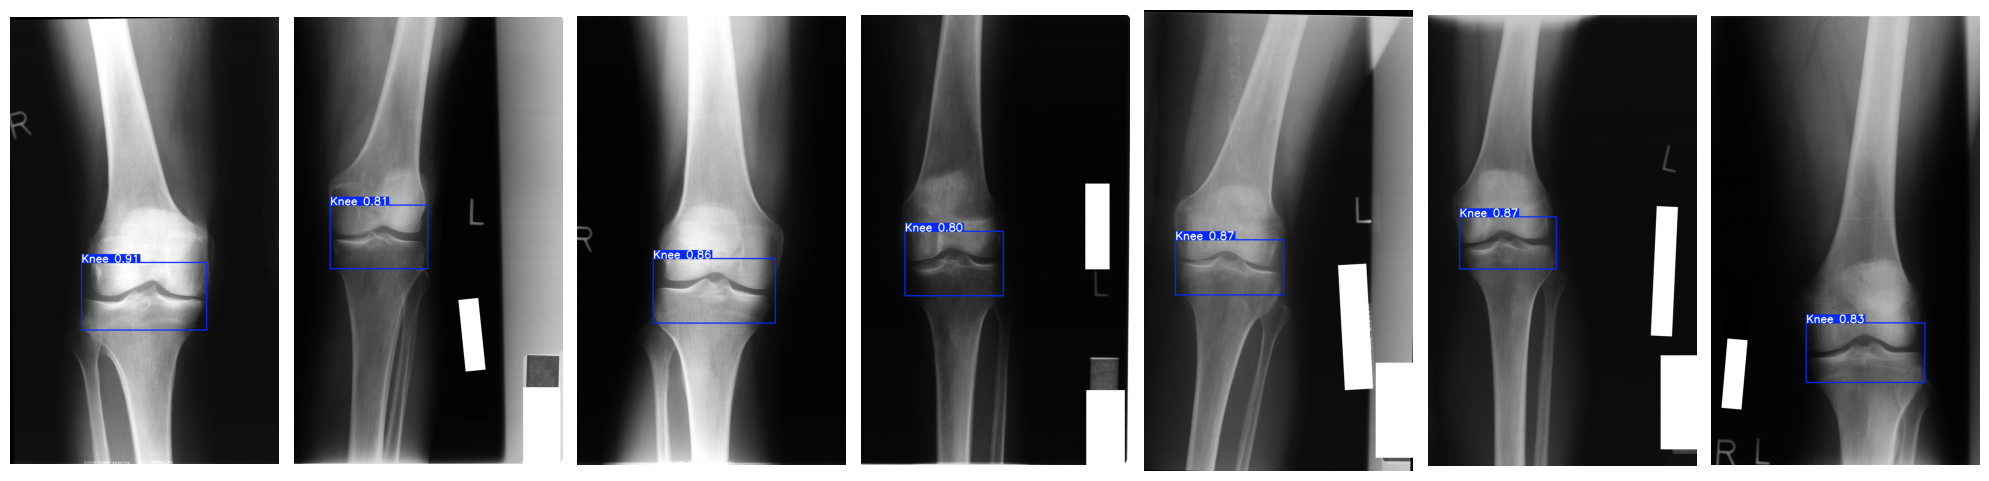

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt

prediction_folder = "/content/runs/detect/predict-2"

prediction_images = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff"]:
    prediction_images.extend(
        glob.glob(os.path.join(prediction_folder, ext))
    )

prediction_images = sorted(prediction_images)

plt.figure(figsize=(20,6))

for i, img_path in enumerate(prediction_images):

    image = cv2.imread(img_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(prediction_images), i+1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

# YOLO prediction folder
SOURCE = "/content/runs/detect/predict-2"

# Destination in Google Drive
DESTINATION = os.path.join(
    PROJECT_DIR,
    "Predictions",
    "YOLO11n_70"
)

# Create Predictions folder if it doesn't exist
os.makedirs(os.path.join(PROJECT_DIR, "Predictions"), exist_ok=True)

# If YOLO11n_70 already exists, create a timestamped backup instead of overwriting
if os.path.exists(DESTINATION):
    import datetime

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    DESTINATION = os.path.join(
        PROJECT_DIR,
        "Predictions",
        f"YOLO11n_70_{timestamp}"
    )

shutil.copytree(SOURCE, DESTINATION)

print("Predictions saved to:")
print(DESTINATION)

Predictions saved to:
/content/drive/MyDrive/Knee_YOLO_Project/Predictions/YOLO11n_70_20260721_182159


# Results Summary

This section summarizes the performance of the YOLO11n model across the different dataset sizes. The evaluation metrics include Precision, Recall, mAP@50, and mAP@50:95. These metrics are used to assess the object detection performance as the training dataset size increases.

In [ ]:
import pandas as pd

results_df = pd.DataFrame([
    results_30,
    results_50,
    results_70
])

results_df

,Dataset Size,Training Images,Validation Images,Test Images,Precision,Recall,mAP@50,mAP@50:95
0,30,24,3,3,0.9860,1.0,0.995,0.775
1,50,40,5,5,0.9860,1.0,0.995,0.775
2,70,56,7,7,0.9927,1.0,0.995,0.763


The table above presents the quantitative evaluation results obtained after training the YOLO11n model using progressively larger datasets. The objective is to observe how increasing the amount of training data influences the model's localization performance.

In [ ]:
results_df.to_csv(
    os.path.join(RESULTS_DIR, "results_summary.csv"),
    index=False
)

print("Results summary saved successfully.")

Results summary saved successfully.


# **Graphs**

In [ ]:
import os

GRAPHS_DIR = os.path.join(PROJECT_DIR, "Graphs")
os.makedirs(GRAPHS_DIR, exist_ok=True)

In [ ]:
import matplotlib.pyplot as plt

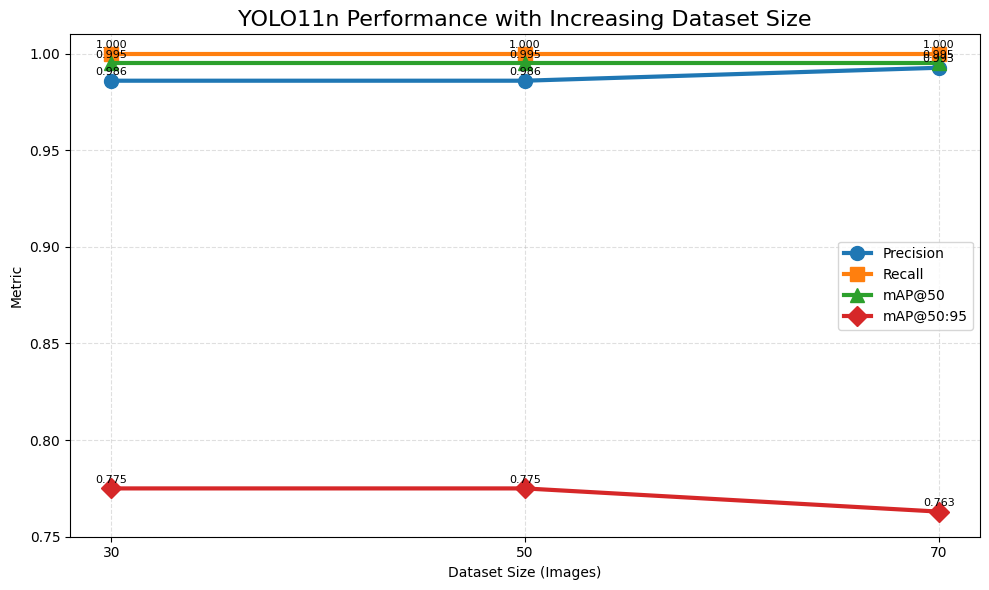

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(results_df["Dataset Size"],
         results_df["Precision"],
         '-o',
         linewidth=3,
         markersize=10,
         label='Precision')

plt.plot(results_df["Dataset Size"],
         results_df["Recall"],
         '-s',
         linewidth=3,
         markersize=10,
         label='Recall')

plt.plot(results_df["Dataset Size"],
         results_df["mAP@50"],
         '-^',
         linewidth=3,
         markersize=10,
         label='mAP@50')

plt.plot(results_df["Dataset Size"],
         results_df["mAP@50:95"],
         '-D',
         linewidth=3,
         markersize=10,
         label='mAP@50:95')

# Display exact values
for metric in ["Precision","Recall","mAP@50","mAP@50:95"]:
    for x, y in zip(results_df["Dataset Size"], results_df[metric]):
        plt.text(x, y+0.003, f"{y:.3f}", ha='center', fontsize=8)

plt.title("YOLO11n Performance with Increasing Dataset Size", fontsize=16)
plt.xlabel("Dataset Size (Images)")
plt.ylabel("Metric")

plt.xticks(results_df["Dataset Size"])
plt.ylim(0.75,1.01)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

#  **Testing the Unseen Images wihout annotating them**

In [ ]:
# Create folder for unknown images

UNKNOWN_IMAGES_DIR = os.path.join(
    PROJECT_DIR,
    "Unknown_Images"
)

os.makedirs(
    UNKNOWN_IMAGES_DIR,
    exist_ok=True
)

print("Unknown Images Folder:")
print(UNKNOWN_IMAGES_DIR)

Unknown Images Folder:
/content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images


In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    os.path.join(
        RESULTS_DIR,
        "YOLO11n_70",
        "weights",
        "best.pt"
    )
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [ ]:
prediction_results = best_model.predict(
    source=UNKNOWN_IMAGES_DIR,
    save=True,
    conf=0.25,
    imgsz=640
)


image 1/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10203K1_L.png: 640x384 1 Knee, 18.1ms
image 2/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10203K1_R.png: 640x384 1 Knee, 10.0ms
image 3/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10236K1_L.png: 640x384 1 Knee, 9.7ms
image 4/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10236K1_R.png: 640x384 1 Knee, 10.3ms
image 5/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10244K1_L.png: 640x384 1 Knee, 10.5ms
image 6/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10244K1_R.png: 640x384 1 Knee, 9.9ms
image 7/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10268K1_L.png: 640x416 1 Knee, 59.1ms
image 8/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10268K1_R.png: 640x416 1 Knee, 14.5ms
image 9/40 /content/drive/MyDrive/Knee_YOLO_Project/Unknown_Images/10271K1_L.png: 640x384 1 Knee, 12.7ms
image 10/40 /content/drive/MyDrive/Knee_YOLO_Project/Unk

In [ ]:
import glob

detect_dir = "/content/runs/detect"

prediction_folders = sorted(
    glob.glob(os.path.join(detect_dir, "predict*")),
    key=os.path.getmtime
)

prediction_folder = prediction_folders[-1]

print(prediction_folder)

/content/runs/detect/predict-3


In [ ]:
import shutil

UNKNOWN_PREDICTIONS_DIR = os.path.join(
    PREDICTIONS_DIR,
    "Unknown_70"
)

os.makedirs(
    UNKNOWN_PREDICTIONS_DIR,
    exist_ok=True
)

for file in os.listdir(prediction_folder):

    shutil.copy(
        os.path.join(prediction_folder, file),
        os.path.join(UNKNOWN_PREDICTIONS_DIR, file)
    )

print("Predictions copied successfully.")

Predictions copied successfully.


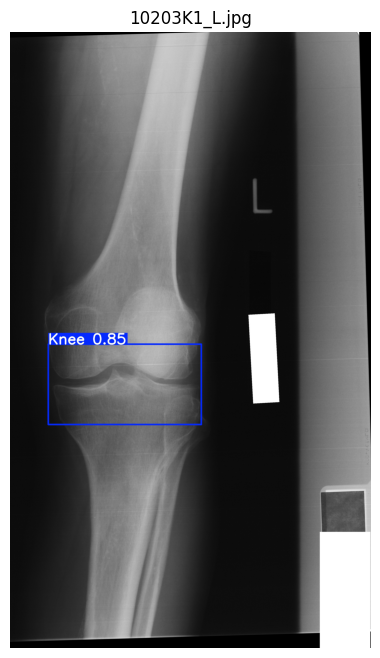

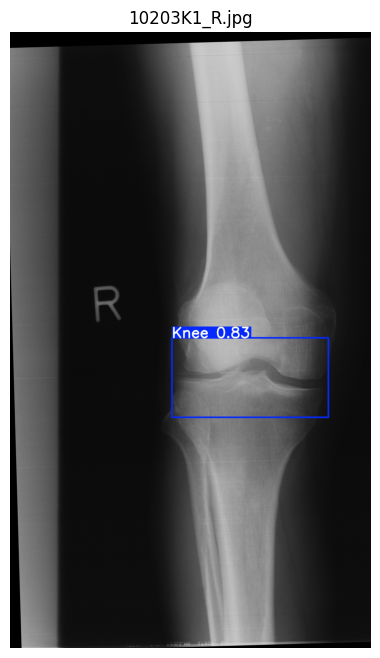

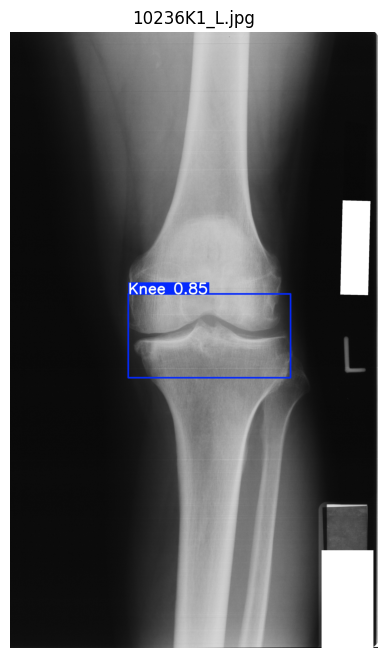

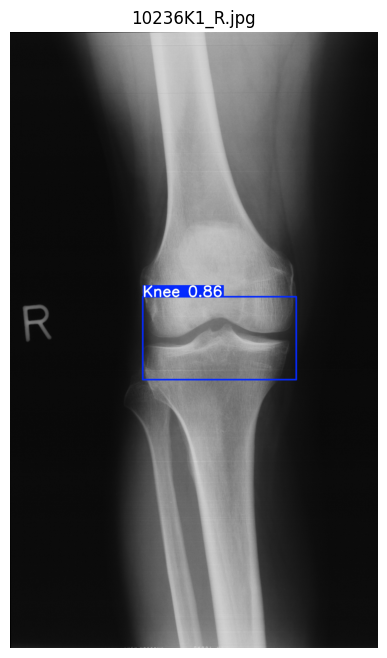

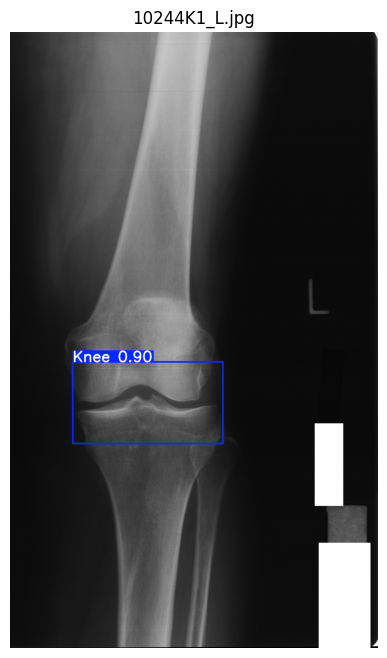

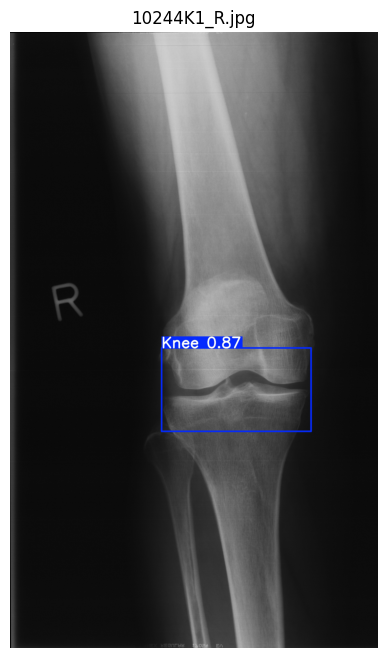

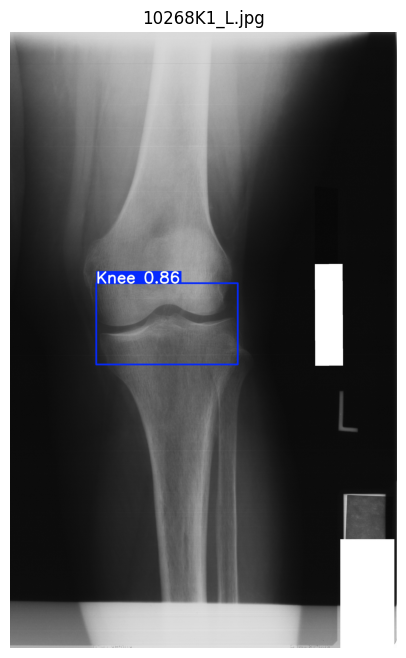

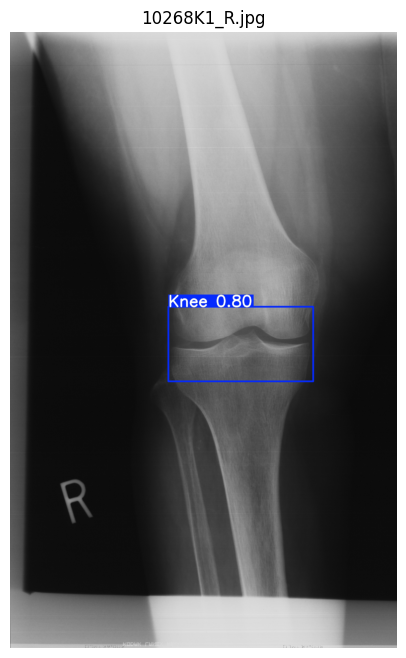

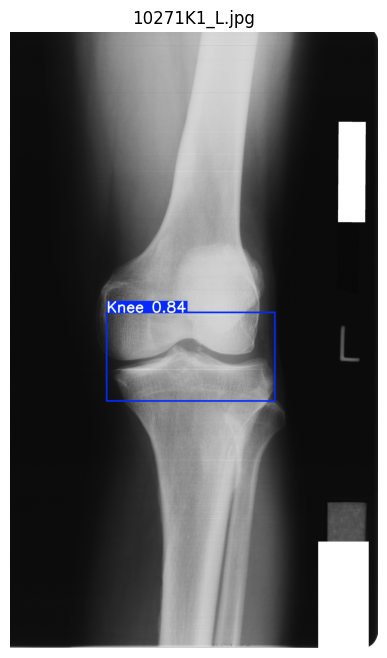

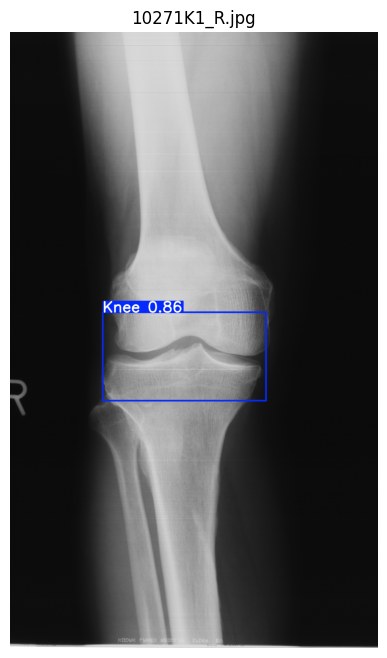

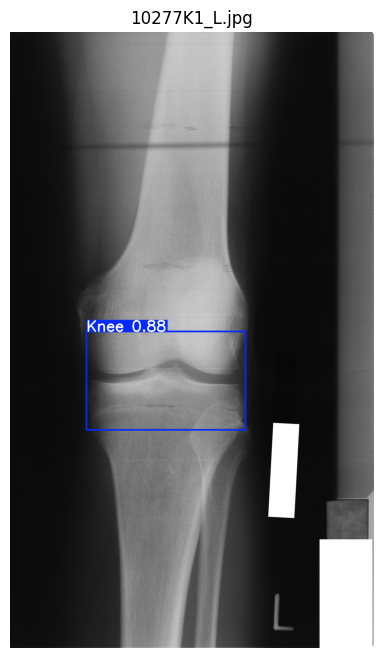

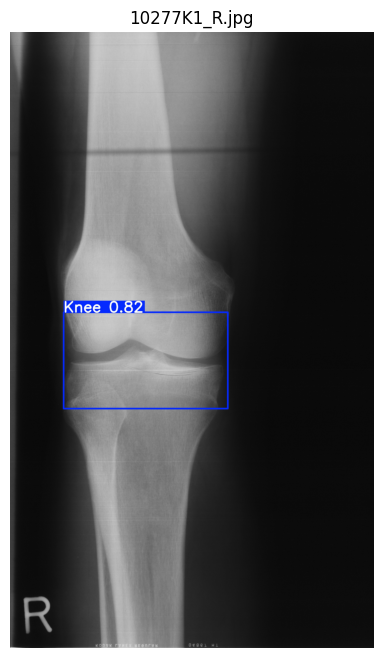

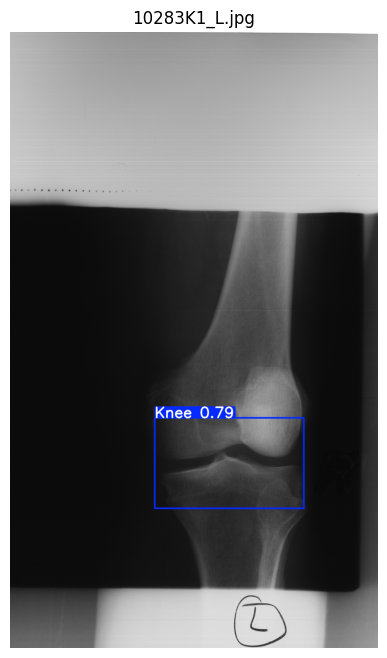

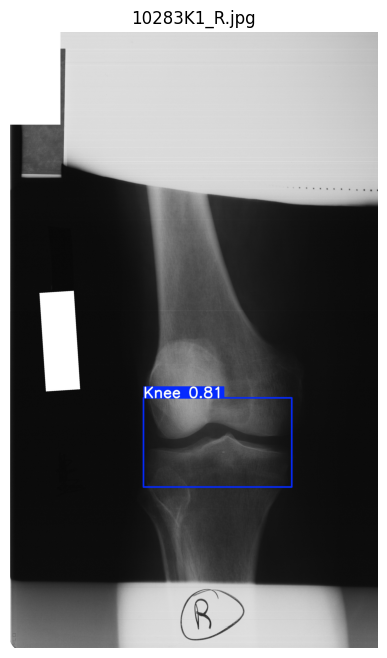

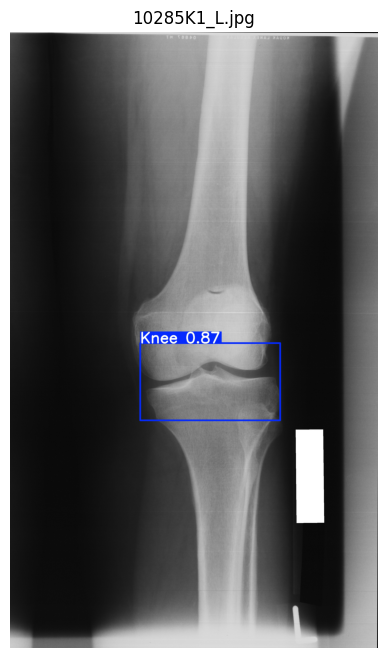

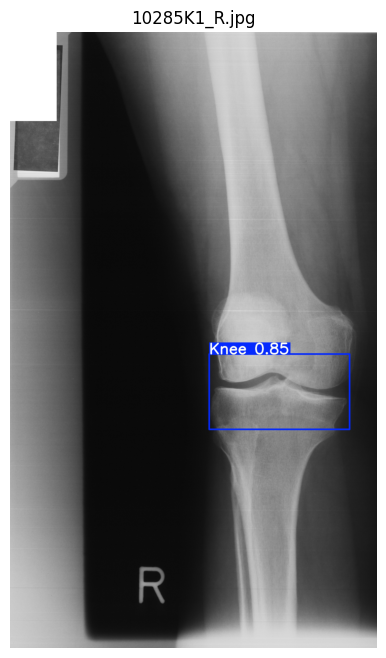

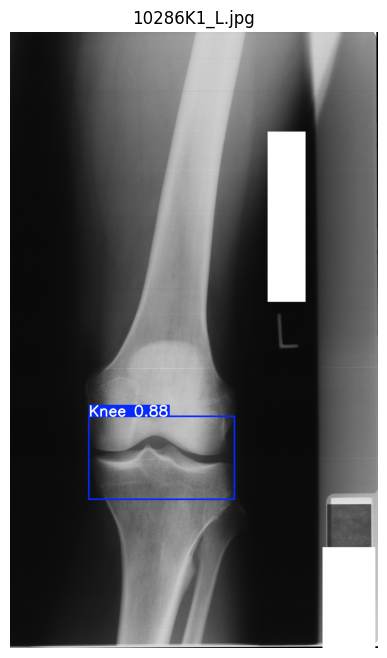

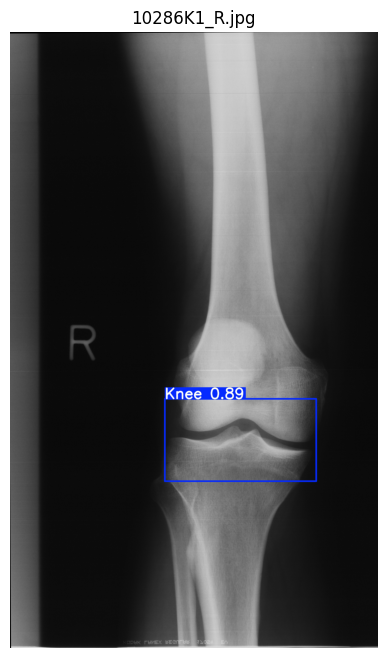

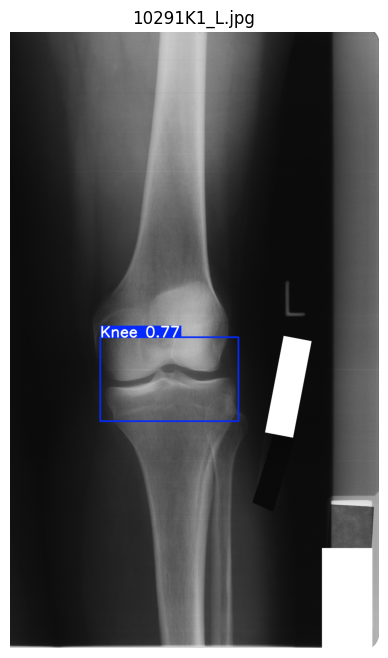

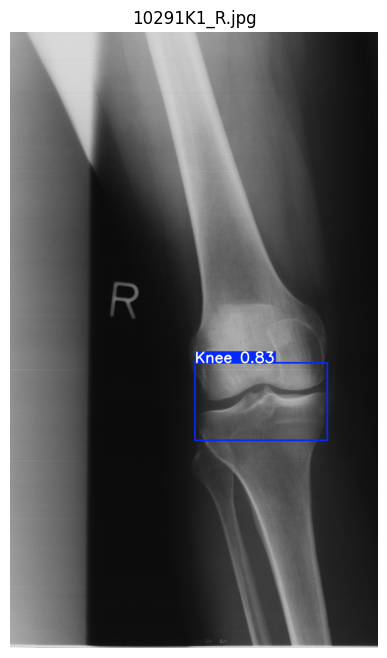

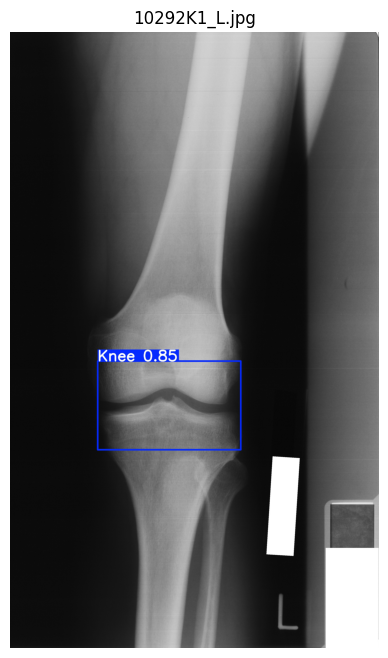

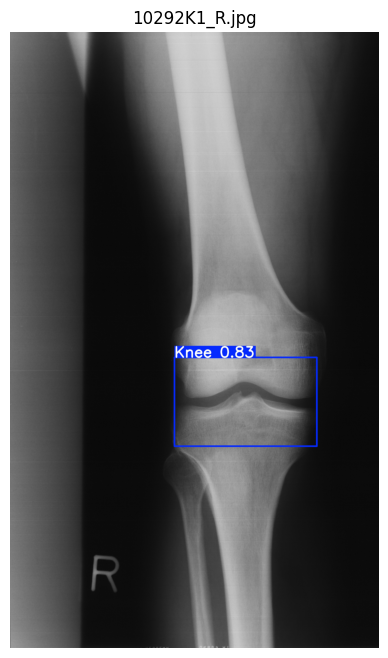

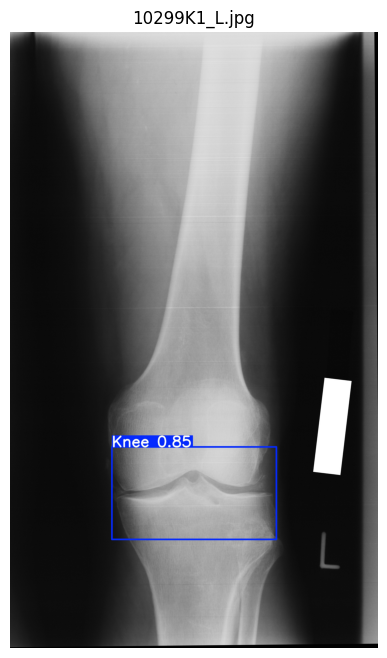

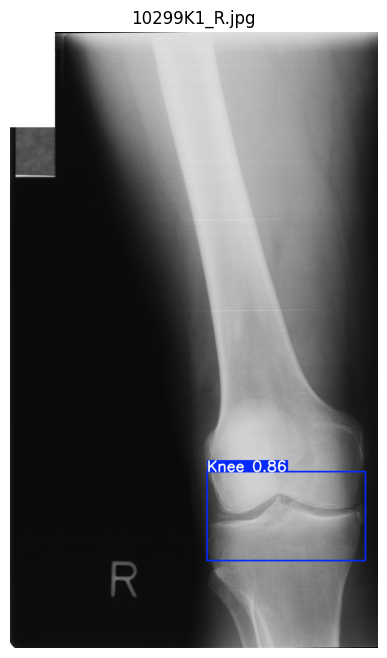

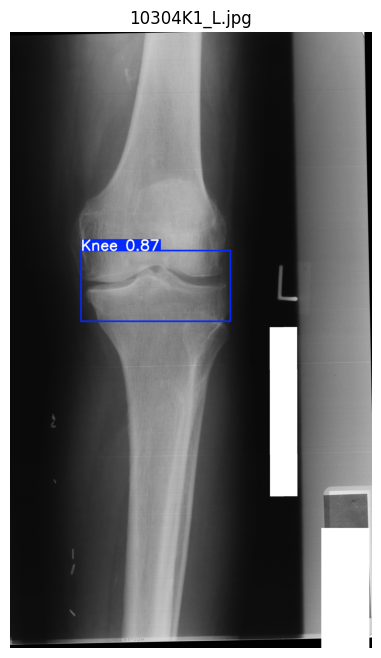

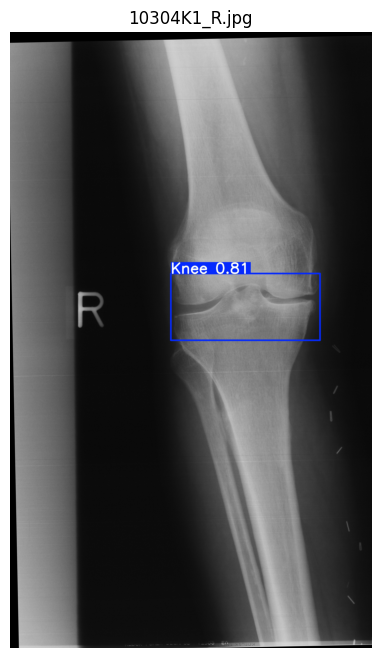

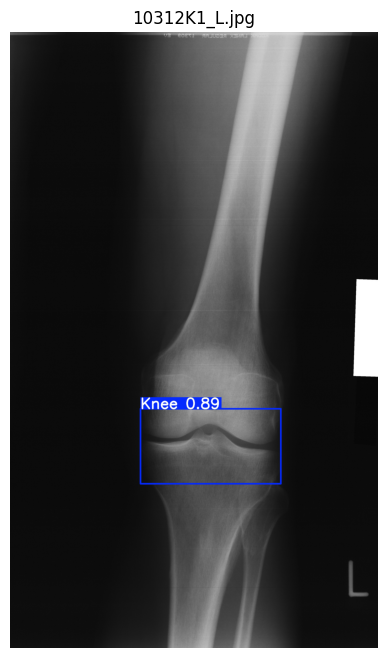

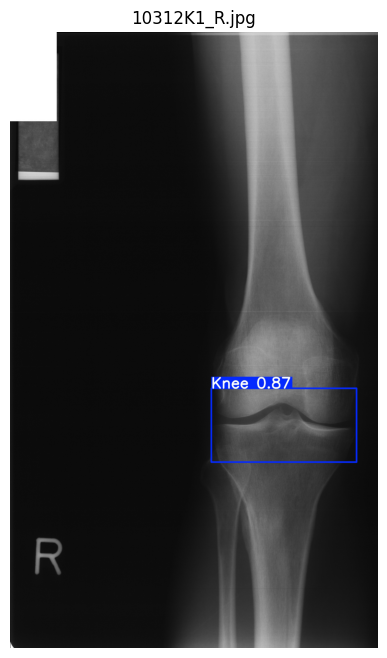

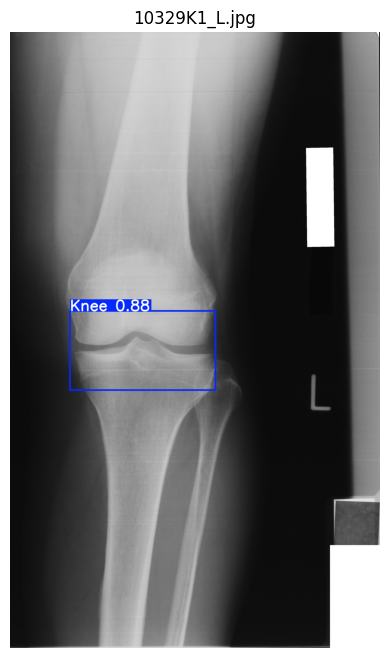

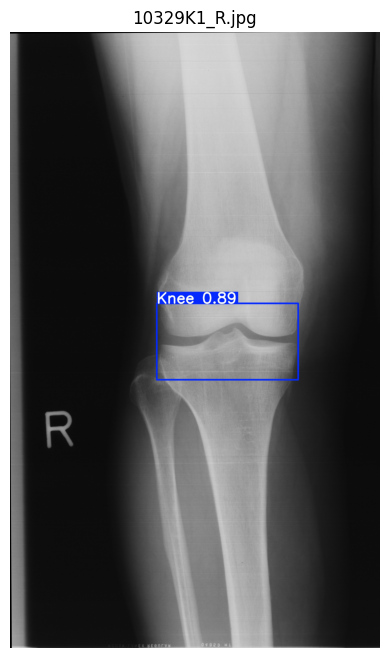

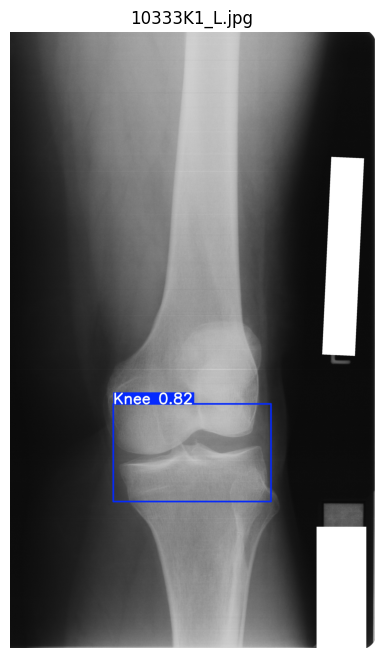

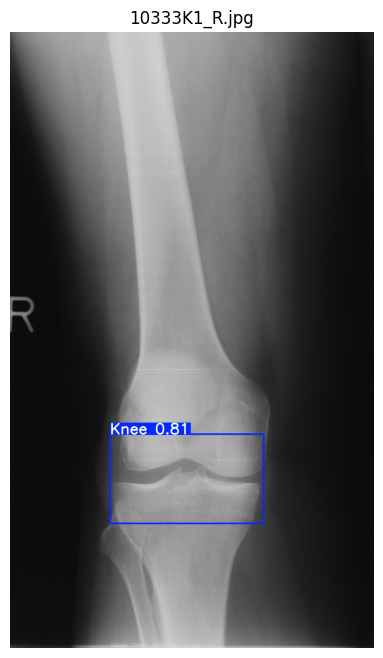

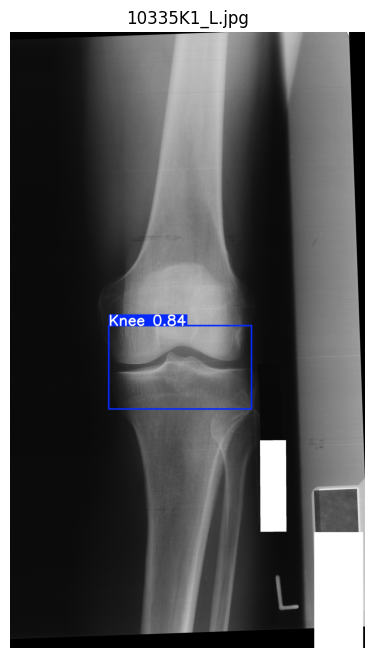

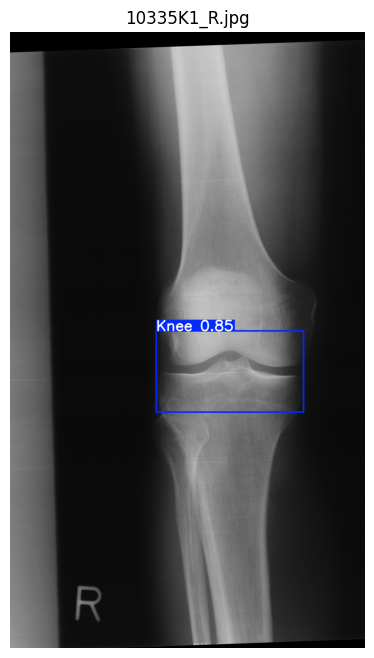

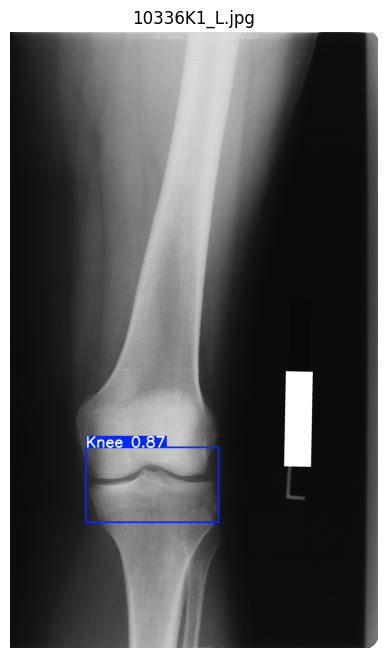

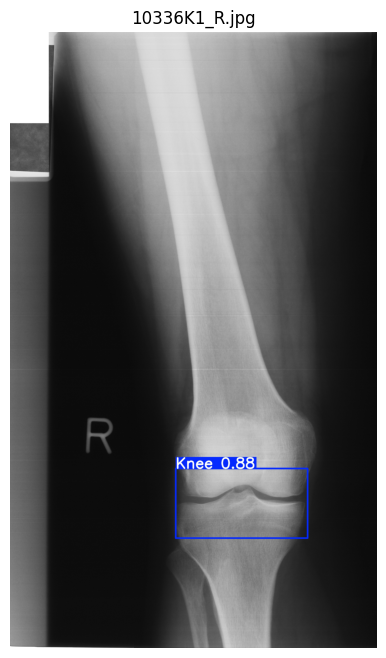

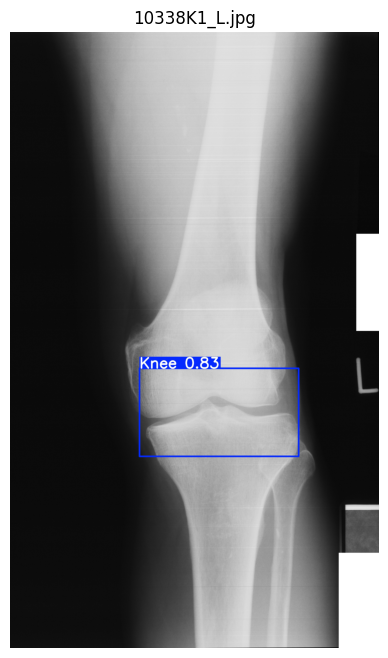

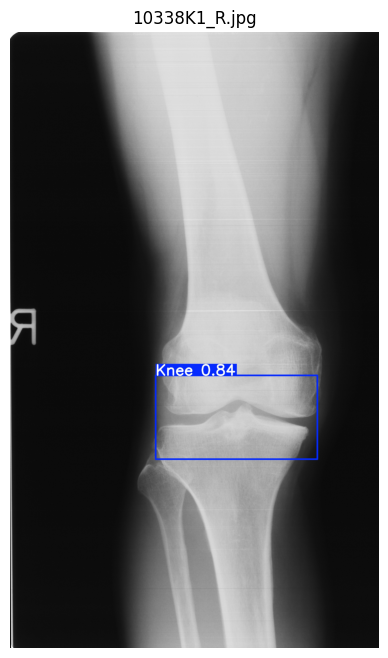

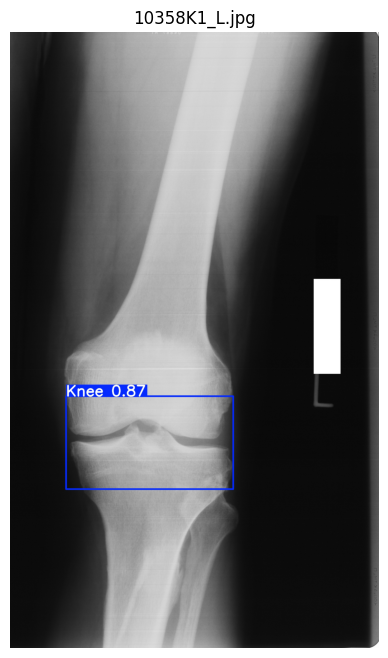

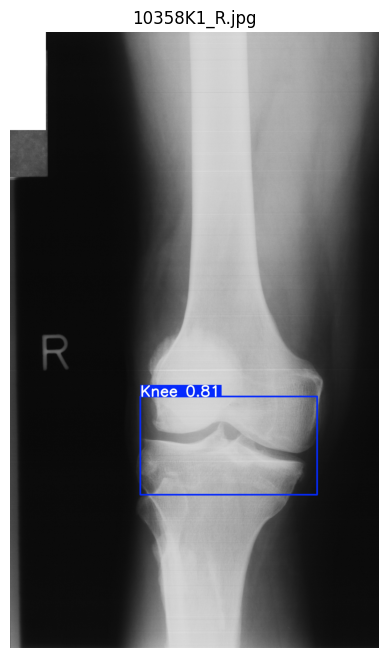

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

prediction_images = sorted(
    os.listdir(UNKNOWN_PREDICTIONS_DIR)
)

for image_name in prediction_images:

    image_path = os.path.join(
        UNKNOWN_PREDICTIONS_DIR,
        image_name
    )

    image = Image.open(image_path)

    plt.figure(figsize=(8,8))
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd

summary = []

for result in prediction_results:

    image_name = os.path.basename(result.path)

    if len(result.boxes) > 0:

        confidence = float(result.boxes.conf.max())

        detection = "Detected"

    else:

        confidence = None

        detection = "Not Detected"

    summary.append({
        "Image": image_name,
        "Detection": detection,
        "Confidence": confidence
    })

summary_df = pd.DataFrame(summary)

summary_df

,Image,Detection,Confidence
0,10203K1_L.png,Detected,0.849070
1,10203K1_R.png,Detected,0.830266
2,10236K1_L.png,Detected,0.846295
3,10236K1_R.png,Detected,0.859892
4,10244K1_L.png,Detected,0.904172
5,10244K1_R.png,Detected,0.873018
6,10268K1_L.png,Detected,0.856077
7,10268K1_R.png,Detected,0.798794
8,10271K1_L.png,Detected,0.842388
9,10271K1_R.png,Detected,0.857805


In [ ]:
summary_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "unknown_image_predictions.csv"
    ),
    index=False
)

print("Prediction summary saved successfully.")

Prediction summary saved successfully.


In [ ]:
from ultralytics import YOLO
from PIL import Image
import os

for filename in sorted(os.listdir(UNKNOWN_IMAGES_DIR)):

    path = os.path.join(UNKNOWN_IMAGES_DIR, filename)

    try:
        img = Image.open(path)

        print(
            filename,
            "Mode:", img.mode,
            "Size:", img.size
        )

        # Test prediction on ONE image
        best_model.predict(
            source=path,
            imgsz=640,
            verbose=False
        )

        print("✓ OK\n")

    except Exception as e:
        print("✗ FAILED:", filename)
        print(e)
        break

10203K1_L.png Mode: RGBA Size: (2503, 4279)
✓ OK

10203K1_R.png Mode: RGBA Size: (2502, 4279)
✓ OK

10236K1_L.png Mode: RGBA Size: (2497, 4183)
✓ OK

10236K1_R.png Mode: RGBA Size: (2496, 4183)
✓ OK

10244K1_L.png Mode: RGBA Size: (2500, 4189)
✓ OK

10244K1_R.png Mode: RGBA Size: (2499, 4189)
✓ OK

10268K1_L.png Mode: RGBA Size: (2497, 3979)
✓ OK

10268K1_R.png Mode: RGBA Size: (2496, 3979)
✓ OK

10271K1_L.png Mode: RGBA Size: (2503, 4195)
✓ OK

10271K1_R.png Mode: RGBA Size: (2502, 4195)
✓ OK

10277K1_L.png Mode: RGBA Size: (2467, 4177)
✓ OK

10277K1_R.png Mode: RGBA Size: (2466, 4177)
✓ OK

10283K1_L.png Mode: RGBA Size: (2503, 4195)
✓ OK

10283K1_R.png Mode: RGBA Size: (2502, 4195)
✓ OK

10285K1_L.png Mode: RGBA Size: (2485, 4171)
✓ OK

10285K1_R.png Mode: RGBA Size: (2484, 4171)
✓ OK

10286K1_L.png Mode: RGBA Size: (2500, 4189)
✓ OK

10286K1_R.png Mode: RGBA Size: (2499, 4189)
✓ OK

10291K1_L.png Mode: RGBA Size: (2503, 4189)
✓ OK

10291K1_R.png Mode: RGBA Size: (2502, 4189)
✓ OK



In [ ]:
prediction_results = best_model.predict(
    source=UNKNOWN_IMAGES_DIR,
    save=True,
    project=PREDICTIONS_DIR,
    name="Unknown_70",
    exist_ok=True,
    conf=0.25,
    imgsz=640
)

print("Predictions saved successfully!")

Results saved to /content/drive/MyDrive/Knee_YOLO_Project/Predictions/Unknown_70
Predictions saved successfully!
